# Step 22 — backtest_model() Experiment Notebook

Lean setup (no full re-derivation like notebook 21) — just enough to call
`backtest_model()` for all three models (A, MA-alone, B) and inspect its
actual output directly. Same BTC data, same reference code.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

np.random.seed(0)

btcusdt = pd.read_csv('BTCUSDT_1d_author_original.csv')
btcusdt['t'] = pd.to_datetime(btcusdt['t'])
btcusdt.set_index('t', inplace=True)

btcusdt['close_log_return'] = np.log(btcusdt['c'] / btcusdt['c'].shift())
btcusdt['close_log_return_lag_1'] = btcusdt['close_log_return'].shift()
# NOTE: MA column deliberately NOT added yet -- Model A must run before it exists,
# matching the author's real cell order. Adding it here would let dropna() inside
# backtest_model() see the MA column's 39 extra warm-up NaNs and silently change
# Model A's Train/Test split. (This bit us on the first version of this notebook.)

print('Loaded:', len(btcusdt), 'rows,', btcusdt.index.min().date(), '->', btcusdt.index.max().date())

Loaded: 2097 rows, 2020-08-19 -> 2026-05-16


In [2]:
# The function under test — author's exact code, unchanged
def backtest_model(df, features, target, test_split=0.25):
    df = df.dropna()
    df_train, df_test = train_test_split(df, test_size=test_split, shuffle=False)
    X_train, X_test, y_train, y_test = df_train[features], df_test[features], df_train[target], df_test[target]
    model = LinearRegression()
    model.fit(X_train, y_train)
    print(model.coef_, model.intercept_)
    backtest = df.copy()
    backtest['y_hat'] = model.predict(backtest[features])
    backtest['signal'] = np.sign(backtest['y_hat'])
    backtest['trade_log_return'] = backtest['close_log_return'] * backtest['signal']
    backtest['cum_trade_log_return'] = backtest['trade_log_return'].cumsum()
    return model, backtest

## Instrumented version — see every container inside backtest_model() in real time

Same function, exact same logic, just with print statements added after each line
so we can watch every internal variable get created and populated, in order.

In [3]:
def backtest_model_debug(df, features, target, test_split=0.25):
    print('>>> STEP 1: df BEFORE dropna, shape =', df.shape)
    df = df.dropna()
    print('>>> STEP 2: df AFTER dropna, shape =', df.shape)
    print(df[features + [target]].head(2))
    print()

    df_train, df_test = train_test_split(df, test_size=test_split, shuffle=False)
    print('>>> STEP 3: df_train shape =', df_train.shape, '  df_test shape =', df_test.shape)
    print('    df_train date range:', df_train.index.min(), '->', df_train.index.max())
    print('    df_test  date range:', df_test.index.min(), '->', df_test.index.max())
    print()

    X_train, X_test, y_train, y_test = df_train[features], df_test[features], df_train[target], df_test[target]
    print('>>> STEP 4: X_train shape =', X_train.shape, ' type =', type(X_train).__name__)
    print(X_train.head(2))
    print('>>> STEP 4: y_train shape =', y_train.shape, ' type =', type(y_train).__name__)
    print(y_train.head(2))
    print()

    model = LinearRegression()
    print('>>> STEP 5: model created (unfitted) =', model)
    model.fit(X_train, y_train)
    print('>>> STEP 6: model AFTER .fit() -> coef_ =', model.coef_, ' intercept_ =', model.intercept_)
    print()

    backtest = df.copy()
    print('>>> STEP 7: backtest = df.copy(), shape =', backtest.shape, '(train+test combined)')
    backtest['y_hat'] = model.predict(backtest[features])
    print('>>> STEP 8: y_hat added, first 2:', backtest['y_hat'].head(2).values)
    backtest['signal'] = np.sign(backtest['y_hat'])
    print('>>> STEP 9: signal added, first 2:', backtest['signal'].head(2).values)
    backtest['trade_log_return'] = backtest['close_log_return'] * backtest['signal']
    print('>>> STEP 10: trade_log_return added, first 2:', backtest['trade_log_return'].head(2).values)
    backtest['cum_trade_log_return'] = backtest['trade_log_return'].cumsum()
    print('>>> STEP 11: cum_trade_log_return added, first 2:', backtest['cum_trade_log_return'].head(2).values)
    print('>>> STEP 11: cum_trade_log_return LAST value:', backtest['cum_trade_log_return'].iloc[-1])

    return model, backtest

_m, _b = backtest_model_debug(btcusdt, ['close_log_return_lag_1'], 'close_log_return')


>>> STEP 1: df BEFORE dropna, shape = (2097, 11)
>>> STEP 2: df AFTER dropna, shape = (2095, 11)
            close_log_return_lag_1  close_log_return
t                                                   
2020-08-21                0.007959         -0.027305
2020-08-22               -0.027305          0.011375

>>> STEP 3: df_train shape = (1571, 11)   df_test shape = (524, 11)
    df_train date range: 2020-08-21 00:00:00 -> 2024-12-08 00:00:00
    df_test  date range: 2024-12-09 00:00:00 -> 2026-05-16 00:00:00

>>> STEP 4: X_train shape = (1571, 1)  type = DataFrame
            close_log_return_lag_1
t                                 
2020-08-21                0.007959
2020-08-22               -0.027305
>>> STEP 4: y_train shape = (1571,)  type = Series
t
2020-08-21   -0.027305
2020-08-22    0.011375
Name: close_log_return, dtype: float64

>>> STEP 5: model created (unfitted) = LinearRegression()
>>> STEP 6: model AFTER .fit() -> coef_ = [-0.02902972]  intercept_ = 0.0014044601590437902


## Test-only prediction — the step the author's code skips

Predict specifically on `X_test` (not the full combined dataframe), and build the
equity curve using ONLY the genuinely out-of-sample Test rows. Compare against the
Test-only slice of the combined curve we already have (`backtest_a` isn't built yet
at this point in the notebook, so this cell is self-contained).

coef_ = [-0.02902972]  intercept_ = 0.0014044601590437902

Test-only final cum_trade_log_return: 0.10078007085098797
Test rows: 524   date range: 2024-12-09 00:00:00 -> 2026-05-16 00:00:00

signal
 1.0    513
-1.0     11
Name: count, dtype: int64


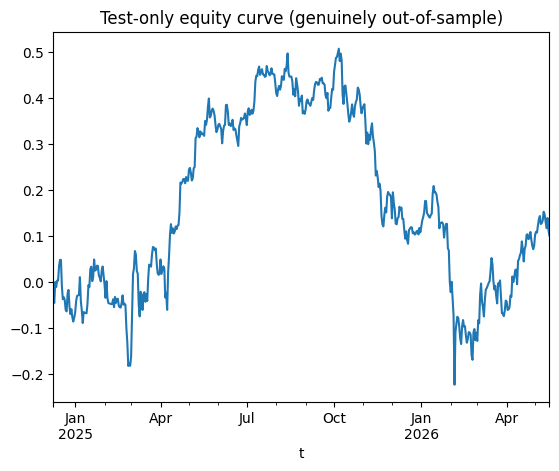

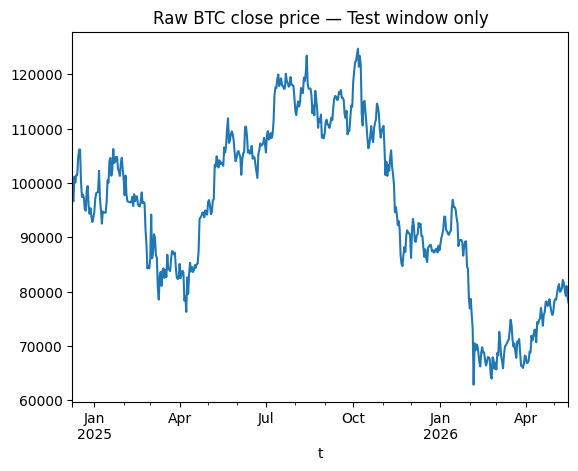

In [4]:
# Self-contained: redo the same split/fit as Model A, but this time actually use X_test/y_test

df_ta = btcusdt.dropna(subset=['close_log_return_lag_1', 'close_log_return'])
df_train_ta, df_test_ta = train_test_split(df_ta, test_size=0.25, shuffle=False)

X_train_ta = df_train_ta[['close_log_return_lag_1']]
X_test_ta = df_test_ta[['close_log_return_lag_1']]
y_train_ta = df_train_ta['close_log_return']
y_test_ta = df_test_ta['close_log_return']

model_ta = LinearRegression()
model_ta.fit(X_train_ta, y_train_ta)
print('coef_ =', model_ta.coef_, ' intercept_ =', model_ta.intercept_)

# Predict ONLY on the held-out Test rows
test_only = df_test_ta.copy()
test_only['y_hat'] = model_ta.predict(X_test_ta)
test_only['signal'] = np.sign(test_only['y_hat'])
test_only['trade_log_return'] = test_only['close_log_return'] * test_only['signal']
test_only['cum_trade_log_return'] = test_only['trade_log_return'].cumsum()

print()
print('Test-only final cum_trade_log_return:', test_only['cum_trade_log_return'].iloc[-1])
print('Test rows:', len(test_only), '  date range:', test_only.index.min(), '->', test_only.index.max())
print()
print(test_only['signal'].value_counts())

test_only['cum_trade_log_return'].plot(title='Test-only equity curve (genuinely out-of-sample)')
plt.show()

test_only['c'].plot(title='Raw BTC close price — Test window only')
plt.show()

## Model A — lag_1 only

[-0.02902972] 0.0014044601590437902

signal
 1.0    1991
-1.0     104
Name: count, dtype: int64


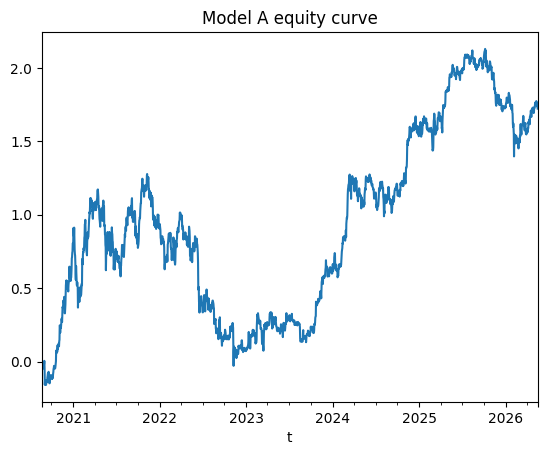

In [5]:
model_a, backtest_a = backtest_model(btcusdt, ['close_log_return_lag_1'], 'close_log_return')
print()
print(backtest_a['signal'].value_counts())
backtest_a['cum_trade_log_return'].plot(title='Model A equity curve')
plt.show()

## MA-alone — ma_lag_1 only

In [6]:
# Add the MA column NOW, after Model A has already run (matches author's real order)
btcusdt['close_log_return_ma_lag_1'] = btcusdt['close_log_return_lag_1'].rolling(40).mean()


[0.28444309] 0.0010530459416579004

signal
 1.0    1689
-1.0     367
Name: count, dtype: int64


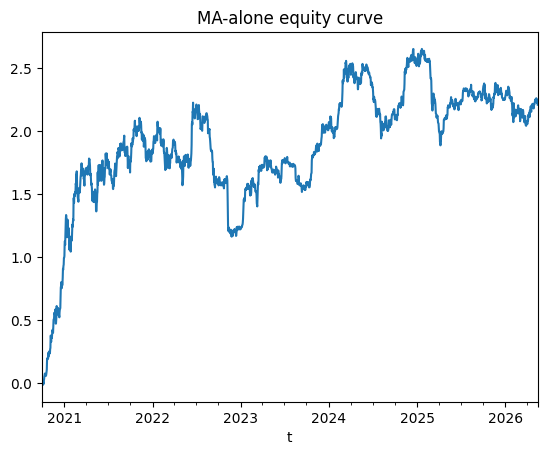

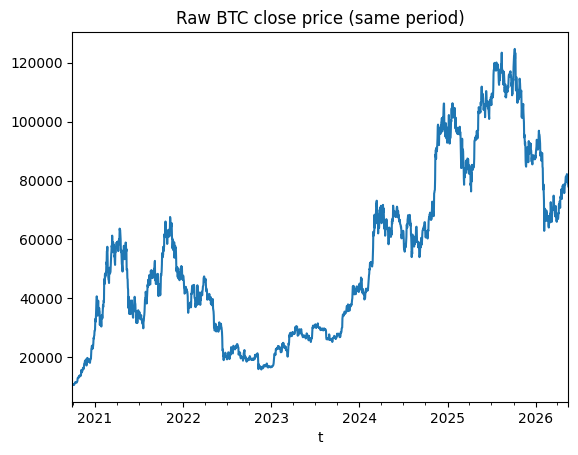

In [7]:
model_ma, backtest_ma = backtest_model(btcusdt, ['close_log_return_ma_lag_1'], 'close_log_return')
print()
print(backtest_ma['signal'].value_counts())
backtest_ma['cum_trade_log_return'].plot(title='MA-alone equity curve')
plt.show()

backtest_ma['c'].plot(title='Raw BTC close price (same period)')
plt.show()

coef_ = [0.28444309]  intercept_ = 0.0010530459416579004

Test-only final cum_trade_log_return: -0.38523493977539575
Test rows: 514   date range: 2024-12-19 00:00:00 -> 2026-05-16 00:00:00

signal
 1.0    416
-1.0     98
Name: count, dtype: int64


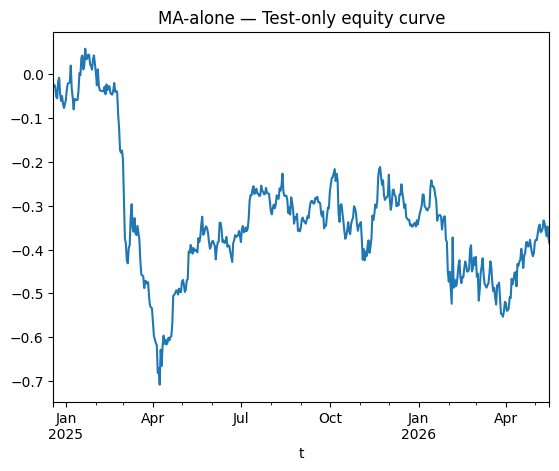

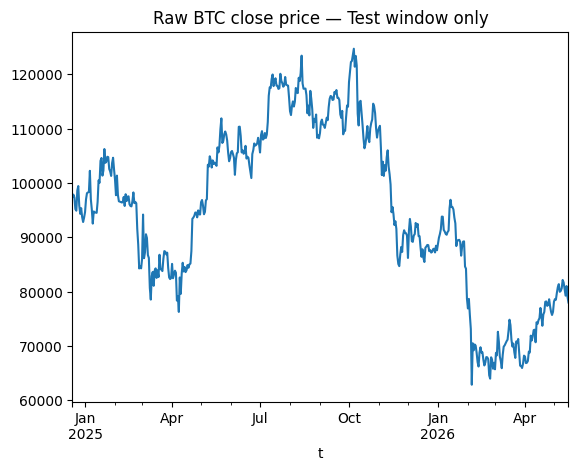

In [8]:
# Test-only prediction — MA-alone
df_ma = btcusdt.dropna(subset=['close_log_return_ma_lag_1', 'close_log_return'])
df_train_ma, df_test_ma = train_test_split(df_ma, test_size=0.25, shuffle=False)

X_train_ma_t = df_train_ma[['close_log_return_ma_lag_1']]
X_test_ma_t = df_test_ma[['close_log_return_ma_lag_1']]
y_train_ma_t = df_train_ma['close_log_return']

model_ma_t = LinearRegression()
model_ma_t.fit(X_train_ma_t, y_train_ma_t)
print('coef_ =', model_ma_t.coef_, ' intercept_ =', model_ma_t.intercept_)

test_only_ma = df_test_ma.copy()
test_only_ma['y_hat'] = model_ma_t.predict(X_test_ma_t)
test_only_ma['signal'] = np.sign(test_only_ma['y_hat'])
test_only_ma['trade_log_return'] = test_only_ma['close_log_return'] * test_only_ma['signal']
test_only_ma['cum_trade_log_return'] = test_only_ma['trade_log_return'].cumsum()

print()
print('Test-only final cum_trade_log_return:', test_only_ma['cum_trade_log_return'].iloc[-1])
print('Test rows:', len(test_only_ma), '  date range:', test_only_ma.index.min(), '->', test_only_ma.index.max())
print()
print(test_only_ma['signal'].value_counts())

test_only_ma['cum_trade_log_return'].plot(title='MA-alone — Test-only equity curve')
plt.show()

test_only_ma['c'].plot(title='Raw BTC close price — Test window only')
plt.show()

## Model B — lag_1 + ma_lag_1 combined

[-0.03820892  0.32349523] 0.0010550240542074696

signal
 1.0    1612
-1.0     444
Name: count, dtype: int64


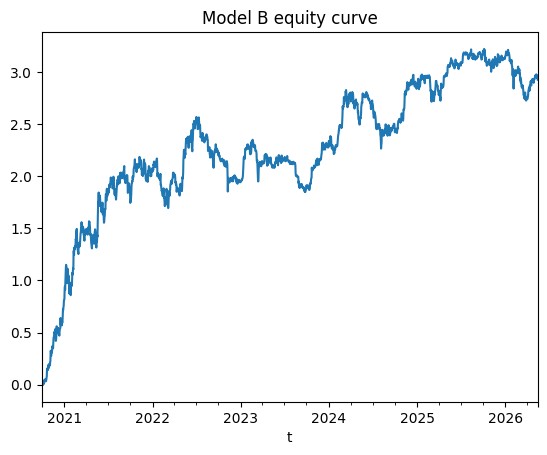

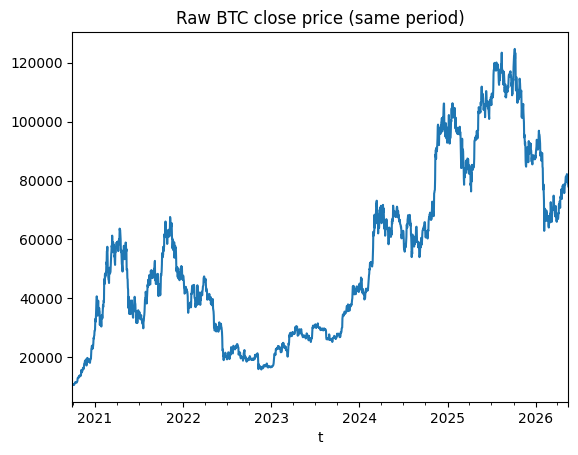

In [9]:
model_b, backtest_b = backtest_model(btcusdt, ['close_log_return_lag_1', 'close_log_return_ma_lag_1'], 'close_log_return')
print()
print(backtest_b['signal'].value_counts())
backtest_b['cum_trade_log_return'].plot(title='Model B equity curve')
plt.show()

backtest_b['c'].plot(title='Raw BTC close price (same period)')
plt.show()

coef_ = [-0.03820892  0.32349523]  intercept_ = 0.0010550240542074696

Test-only final cum_trade_log_return: 0.010385833510265424
Test rows: 514   date range: 2024-12-19 00:00:00 -> 2026-05-16 00:00:00

signal
 1.0    403
-1.0    111
Name: count, dtype: int64


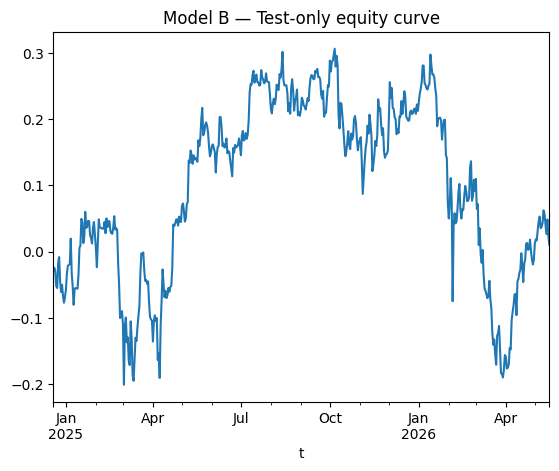

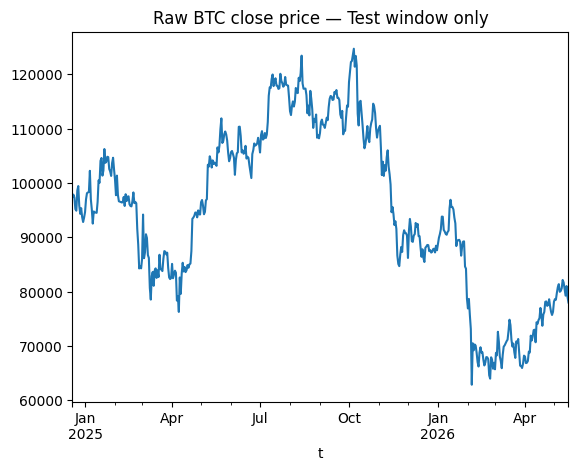

In [10]:
# Test-only prediction — Model B (combined)
df_b = btcusdt.dropna(subset=['close_log_return_lag_1', 'close_log_return_ma_lag_1', 'close_log_return'])
df_train_b, df_test_b = train_test_split(df_b, test_size=0.25, shuffle=False)

features_b = ['close_log_return_lag_1', 'close_log_return_ma_lag_1']
X_train_b_t = df_train_b[features_b]
X_test_b_t = df_test_b[features_b]
y_train_b_t = df_train_b['close_log_return']

model_b_t = LinearRegression()
model_b_t.fit(X_train_b_t, y_train_b_t)
print('coef_ =', model_b_t.coef_, ' intercept_ =', model_b_t.intercept_)

test_only_b = df_test_b.copy()
test_only_b['y_hat'] = model_b_t.predict(X_test_b_t)
test_only_b['signal'] = np.sign(test_only_b['y_hat'])
test_only_b['trade_log_return'] = test_only_b['close_log_return'] * test_only_b['signal']
test_only_b['cum_trade_log_return'] = test_only_b['trade_log_return'].cumsum()

print()
print('Test-only final cum_trade_log_return:', test_only_b['cum_trade_log_return'].iloc[-1])
print('Test rows:', len(test_only_b), '  date range:', test_only_b.index.min(), '->', test_only_b.index.max())
print()
print(test_only_b['signal'].value_counts())

test_only_b['cum_trade_log_return'].plot(title='Model B — Test-only equity curve')
plt.show()

test_only_b['c'].plot(title='Raw BTC close price — Test window only')
plt.show()

## Side-by-side comparison — all three equity curves on one chart

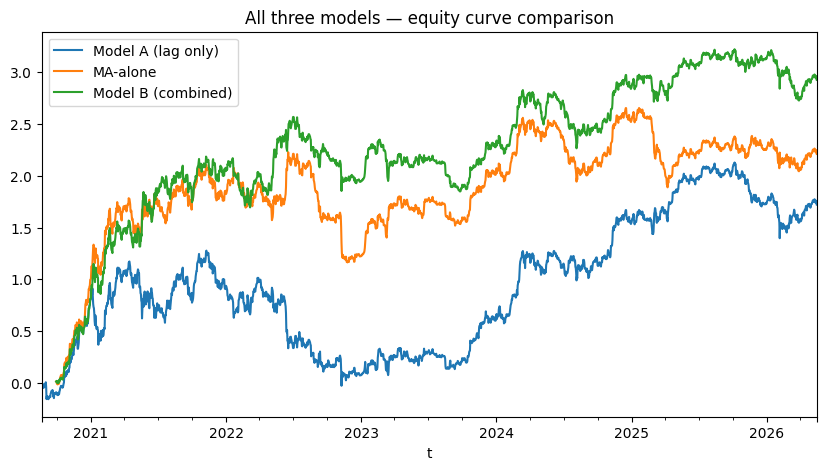

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
backtest_a['cum_trade_log_return'].plot(ax=ax, label='Model A (lag only)')
backtest_ma['cum_trade_log_return'].plot(ax=ax, label='MA-alone')
backtest_b['cum_trade_log_return'].plot(ax=ax, label='Model B (combined)')
ax.set_title('All three models — equity curve comparison')
ax.legend()
plt.show()